In [84]:
import os
import sys
import yaml
import time

import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import healsparse as hs
import healpy as hp
from astropy.io import fits
from astropy.table import Table

txpipe_dir = os.path.join(os.environ["HOME"], "TXPipe")
sys.path.append(txpipe_dir)
if os.getcwd().endswith("notebooks"):
    os.chdir("..")

from txpipe.random_cats import TXRandomCat
import ceci
from pprint import pprint

In [30]:
def print_hdf5_structure(file='/global/homes/k/kabelo/TXPipe/data/example/inputs/photometry_catalog.hdf5'):
    with h5py.File(file, 'r') as f:
        print("Keys in the HDF5 file:")
        def print_structure(name, obj):
            print(f"{name}: {type(obj).__name__}")
        f.visititems(print_structure)

def hdf5_to_df(file='/global/homes/k/kabelo/TXPipe/data/example/inputs/photometry_catalog.hdf5', group=None):
    with h5py.File(file, 'r') as f:
        data_dict = {}
        if group:
            for k in f[group].keys():
                data_dict[k] = f[group][k][:]
        else:
            for k in f.keys():
                if k != 'provenance':
                    group = k
            for k in f[group].keys():
                data_dict[k] = f[group][k][:]
        df = pd.DataFrame(data_dict)
    return df

    
def bin_clusters(infile, zbin_edges, lbin_edges):
    if infile.endswith('.hdf5') or infile.endswith('.h5'):
        with h5py.File(infile, 'r') as f:
            main_group = f['cluster_bin']
            # Read from the first (and assumedly only) subgroup
            subgroup = main_group[list(main_group.keys())[0]]
            data = {col: subgroup[col][:] for col in subgroup.keys()}
        clusters = pd.DataFrame(data)
    else:
        clusters = pd.read_csv(infile)

    clusters['zbin'] = pd.cut(des['redshift'], bins=zbin_edges)
    clusters['lbin'] = pd.cut(des['richness'], bins=lbin_edges)

    bin_dfs = {}
    for (zbin_label, lbin_label), df in clusters.groupby(['zbin', 'lbin'], observed=True):
        bin_dfs[(zbin_label, lbin_label)] = df

    return bin_dfs

    
def df_to_hdf5(bin_dfs, outfile):
    # Build sorted unique labels to map to integer indices
    z_labels = sorted(set(k[0] for k in bin_dfs.keys()))
    l_labels = sorted(set(k[1] for k in bin_dfs.keys()))

    with h5py.File(outfile, 'w') as f:
        main_group = f.create_group('cluster_bin')

        for (zbin_label, lbin_label), df in bin_dfs.items():
            zbin_idx = z_labels.index(zbin_label)
            lbin_idx = l_labels.index(lbin_label)

            group_name = f'bin_zbin_{zbin_idx}_richbin_{lbin_idx}'
            bin_group = main_group.create_group(group_name)

            df = df.drop(columns=['zbin', 'lbin'])

            for col_name in df.columns:
                data = df[col_name].values
                if pd.api.types.is_string_dtype(df[col_name]):
                    string_dtype = h5py.string_dtype(encoding='utf-8')
                    bin_group.create_dataset(col_name, data=data.astype(string_dtype), compression="gzip")
                else:
                    bin_group.create_dataset(col_name, data=data, compression="gzip")

# will want to try this using different exposure/depth maps, could be whats driving this

In [52]:
photometry = hdf5_to_df()
photometry['snr_i'].mean(), photometry['snr_i'].median(), photometry['snr_i'].max(), photometry['snr_i'].min()

(np.float64(33.329831672344135),
 np.float64(6.17336986169975),
 np.float64(18484.96498472502),
 np.float64(0.0))

In [59]:
clusters = hdf5_to_df('/global/homes/k/kabelo/TXPipe/data/example/inputs/photometry_catalog.hdf5')
clusters

,dec,extendedness,g_mag,g_mag_err,i_mag,i_mag_err,id,mag_err_g,mag_err_i,mag_err_r,...,snr_r,snr_u,snr_y,snr_z,u_mag,u_mag_err,y_mag,y_mag_err,z_mag,z_mag_err
0,-30.012834,1.0,20.487791,0.000709,20.052046,0.000993,3437500079,0.000709,0.000993,0.000811,...,1338.499233,216.774744,314.328004,669.346694,21.672545,0.005009,19.952085,0.003454,20.004635,0.001622
1,-30.097206,1.0,20.976517,0.001112,20.385608,0.001350,3437500084,0.001112,0.001350,0.001168,...,929.228664,165.815166,244.627423,511.324500,21.963506,0.006548,20.224280,0.004438,20.297021,0.002123
2,-30.752347,1.0,20.558272,0.000757,19.899142,0.000863,3437500174,0.000757,0.000863,0.000764,...,1420.723170,239.118300,397.576052,823.847951,21.566034,0.004541,19.696992,0.002731,19.779145,0.001318
3,-30.118557,1.0,21.847921,0.002482,21.314772,0.003178,3437500194,0.002482,0.003178,0.002681,...,404.995064,64.666690,97.737066,208.783015,22.985865,0.016790,21.220395,0.011109,21.269525,0.005200
4,-30.962028,1.0,17.834691,0.000062,17.170484,0.000070,3437500209,0.000062,0.000070,0.000062,...,17557.217076,2977.283470,4906.622419,10185.840850,18.828016,0.000365,16.968586,0.000221,17.048770,0.000107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82195,-30.958562,1.0,26.325488,0.153381,inf,0.346437,4269515710,0.153381,0.346437,0.213319,...,5.089727,0.000000,0.000000,0.000000,inf,0.700214,inf,1.466279,inf,0.606150
82196,-30.947296,1.0,26.759665,0.228793,26.100601,0.260884,4269524754,0.228793,0.260884,0.250632,...,4.332000,0.000000,0.000000,0.000000,inf,1.698531,inf,0.856968,inf,0.376713
82197,-30.998789,1.0,26.017029,0.115449,25.702212,0.180756,4270145553,0.115449,0.180756,0.119185,...,9.109664,0.000000,0.000000,0.000000,inf,1.994317,inf,0.719946,inf,0.327976
82198,-30.980917,1.0,26.903624,0.261232,inf,0.483739,4270573215,0.261232,0.483739,0.333536,...,0.000000,0.000000,0.000000,0.000000,inf,1.563855,inf,2.222618,inf,0.868679


In [11]:
!ceci /global/homes/k/kabelo/TXPipe/examples/randoms/long_randoms_pipeline.yml


Executing TXAuxiliaryLensMaps
Command is:
OMP_NUM_THREADS=1 PYTHONPATH=submodules/pyfsb:$PYTHONPATH  python3 -m txpipe TXAuxiliaryLensMaps   --photometry_catalog=data/example/inputs/photometry_catalog.hdf5   --config=examples/randoms/config_randomsonly.yml   --aux_lens_maps=data/example/outputs_randoms_snr25/aux_lens_maps.hdf5 
Output writing to examples/randoms/logs/TXAuxiliaryLensMaps.out

Job TXAuxiliaryLensMaps has completed successfully in 3.0 seconds

Executing TXStarCatalogSplitter
Command is:
OMP_NUM_THREADS=1 PYTHONPATH=submodules/pyfsb:$PYTHONPATH  python3 -m txpipe TXStarCatalogSplitter   --star_catalog=data/example/inputs/star_catalog.hdf5   --config=examples/randoms/config_randomsonly.yml   --binned_star_catalog=data/example/outputs_randoms_snr25/binned_star_catalog.hdf5 
Output writing to examples/randoms/logs/TXStarCatalogSplitter.out

Job TXStarCatalogSplitter has completed successfully in 2.0 seconds

Executing FlowCreator
Command is:
OMP_NUM_THREADS=1 PYTHONPATH=subm

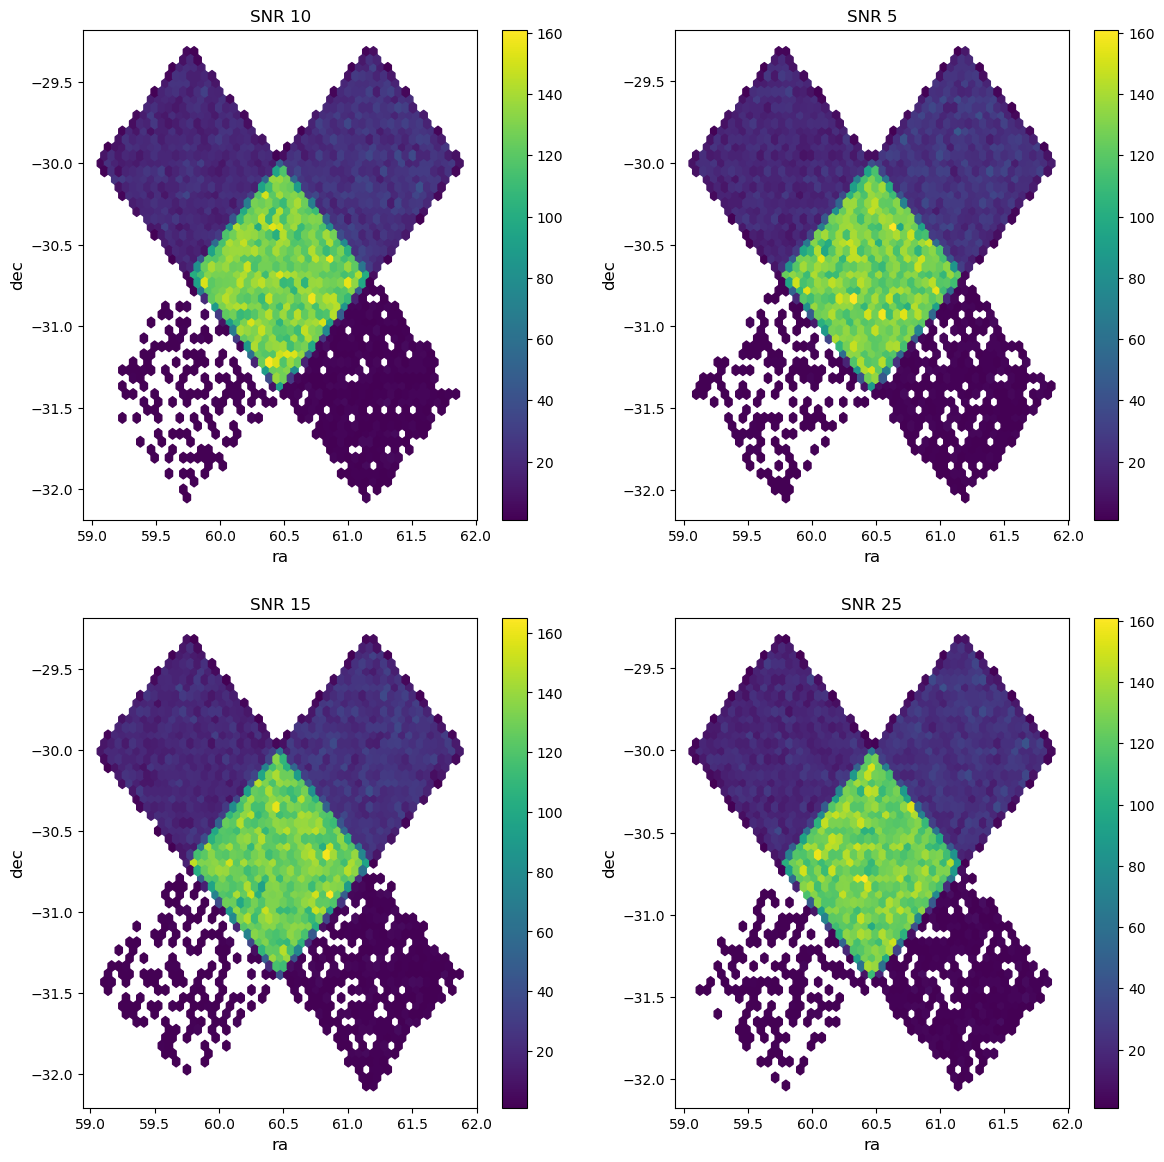

In [16]:

fig, axs = plt.subplots(2, 2, figsize=(14, 14))
f = h5py.File('/global/homes/k/kabelo/TXPipe/data/example/outputs_randoms/random_cats.hdf5')
ra = f['randoms']['ra'][:]
dec = f['randoms']['dec'][:]
im = axs[0, 0].hexbin(ra, dec, 
               gridsize=50, 
               mincnt=1)

cbar = plt.colorbar(im, ax=axs[0, 0])
axs[0, 0].set_xlabel('ra', fontsize=12)
axs[0, 0].set_ylabel('dec', fontsize=12)
axs[0, 0].set_title('SNR 10')

f = h5py.File('/global/homes/k/kabelo/TXPipe/data/example/outputs_randoms_snr5/random_cats.hdf5')
ra = f['randoms']['ra'][:]
dec = f['randoms']['dec'][:]
im = axs[0, 1].hexbin(ra, dec, 
               gridsize=50, 
               mincnt=1)

cbar = plt.colorbar(im, ax=axs[0, 1])
axs[0, 1].set_xlabel('ra', fontsize=12)
axs[0, 1].set_ylabel('dec', fontsize=12)
axs[0, 1].set_title('SNR 5')

f = h5py.File('/global/homes/k/kabelo/TXPipe/data/example/outputs_randoms_snr15/random_cats.hdf5')
ra = f['randoms']['ra'][:]
dec = f['randoms']['dec'][:]
im = axs[1, 0].hexbin(ra, dec, 
               gridsize=50, 
               mincnt=1)

cbar = plt.colorbar(im, ax=axs[1, 0])
axs[1, 0].set_xlabel('ra', fontsize=12)
axs[1, 0].set_ylabel('dec', fontsize=12)
axs[1, 0].set_title('SNR 15')

f = h5py.File('/global/homes/k/kabelo/TXPipe/data/example/outputs_randoms_snr25/random_cats.hdf5')
ra = f['randoms']['ra'][:]
dec = f['randoms']['dec'][:]
im = axs[1, 1].hexbin(ra, dec, 
               gridsize=50, 
               mincnt=1)

cbar = plt.colorbar(im, ax=axs[1, 1])
axs[1, 1].set_xlabel('ra', fontsize=12)
axs[1, 1].set_ylabel('dec', fontsize=12)
axs[1, 1].set_title('SNR 25')
plt.show()

In [24]:
!ceci /global/homes/k/kabelo/TXPipe/examples/randoms/long_randoms_pipeline.yml


Executing TXAuxiliaryLensMaps
Command is:
OMP_NUM_THREADS=1 PYTHONPATH=submodules/pyfsb:$PYTHONPATH  python3 -m txpipe TXAuxiliaryLensMaps   --photometry_catalog=data/example/inputs/photometry_catalog.hdf5   --config=examples/randoms/config_randomsonly.yml   --aux_lens_maps=data/example/outputs_randoms_nside128/aux_lens_maps.hdf5 
Output writing to examples/randoms/logs/TXAuxiliaryLensMaps.out

Job TXAuxiliaryLensMaps has completed successfully in 10.0 seconds

Executing TXStarCatalogSplitter
Command is:
OMP_NUM_THREADS=1 PYTHONPATH=submodules/pyfsb:$PYTHONPATH  python3 -m txpipe TXStarCatalogSplitter   --star_catalog=data/example/inputs/star_catalog.hdf5   --config=examples/randoms/config_randomsonly.yml   --binned_star_catalog=data/example/outputs_randoms_nside128/binned_star_catalog.hdf5 
Output writing to examples/randoms/logs/TXStarCatalogSplitter.out

Job TXStarCatalogSplitter has completed successfully in 2.0 seconds

Executing FlowCreator
Command is:
OMP_NUM_THREADS=1 PYTHONPA

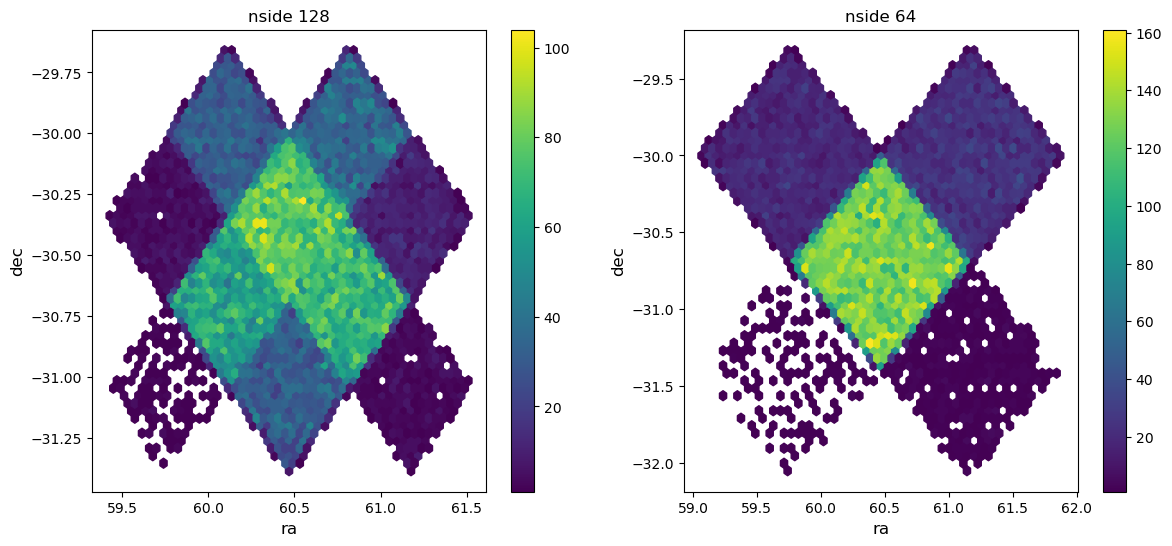

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
f = h5py.File('/global/homes/k/kabelo/TXPipe/data/example/outputs_randoms_nside128/random_cats.hdf5')
ra = f['randoms']['ra'][:]
dec = f['randoms']['dec'][:]
im = axs[0].hexbin(ra, dec, 
               gridsize=50, 
               mincnt=1)

cbar = plt.colorbar(im, ax=axs[0])
axs[0].set_xlabel('ra', fontsize=12)
axs[0].set_ylabel('dec', fontsize=12)
axs[0].set_title('nside 128')

f = h5py.File('/global/homes/k/kabelo/TXPipe/data/example/outputs_randoms/random_cats.hdf5')
ra = f['randoms']['ra'][:]
dec = f['randoms']['dec'][:]
im = axs[1].hexbin(ra, dec, 
               gridsize=50, 
               mincnt=1)

cbar = plt.colorbar(im, ax=axs[1])
axs[1].set_xlabel('ra', fontsize=12)
axs[1].set_ylabel('dec', fontsize=12)
axs[1].set_title('nside 64')

plt.show()

# Clusters

In [104]:
def create_hsp_map(filename='/global/homes/k/kabelo/TXPipe/data/des/y1a1_gold_1.0.2_wide_footprint_4096.fits.gz', partial=False):
    hpx_map = hp.read_map(filename, partial=partial, nest=True)
    nside = hp.get_nside(hpx_map)    
    nside_coverage = 32
    sentinel = hp.UNSEEN
    valid_pixels = np.where(hpx_map != hp.UNSEEN)[0]
    
    hsp_map = hs.HealSparseMap.make_empty(nside_coverage, nside, dtype=hpx_map.dtype, sentinel=hp.UNSEEN)
    hsp_map[valid_pixels] = hpx_map[valid_pixels]
    print(f"NSIDE: {nside}")
    print(f"Map values: min={hpx_map[valid_pixels].min()}, max={hpx_map[valid_pixels].max()}")
    
    print(f"NSIDE: {nside}")
    print(f"Map values: min={hpx_map.min()}, max={hpx_map.max()}")

    print(f"Number of good pixels: {len(valid_pixels)}")
    hsp_valid = hsp_map.valid_pixels
    match = np.array_equal(np.sort(valid_pixels), np.sort(hsp_valid))
    print(f"Pixels match: {match}")
    if not match:
        valid_set = set(valid_pixels)
        hsp_set = set(hsp_valid)
        
        only_in_hpx = np.array(sorted(valid_set - hsp_set))
        only_in_hsp = np.array(sorted(hsp_set - valid_set))
        
        print(f"\nTotal valid_pixels (healpy): {len(valid_pixels)}")
        print(f"Total valid_pixels (healsparse): {len(hsp_valid)}")
        print(f"Pixels only in healpy map: {len(only_in_hpx)}")
        print(f"Pixels only in healsparse map: {len(only_in_hsp)}")
        
        if len(only_in_hpx) > 0:
            print(f"\nSample pixels only in healpy (first 10): {only_in_hpx[:10]}")
            print(f"Their healpy values: {hpx_map[only_in_hpx[:10]]}")
        
        if len(only_in_hsp) > 0:
            print(f"\nSample pixels only in healsparse (first 10): {only_in_hsp[:10]}")
            print(f"Their healsparse values: {hsp_map[only_in_hsp[:10]]}")
        
        # Check if it's purely a count mismatch or actual pixel index disagreement
        overlap = valid_set & hsp_set
        print(f"\nPixels in common: {len(overlap)}")
        print(f"Jaccard similarity: {len(overlap) / len(valid_set | hsp_set):.4f}")
    return hsp_map, hpx_map


def plot_map(filename='/global/homes/k/kabelo/TXPipe/data/des/y1a1_gold_1.0.2_wide_footprint_4096.fits.gz', partial=False):
    hsp_map, hpx_map = create_hsp_map(filename, partial)
    vpix, ra, dec = hsp_map.valid_pixels_pos(return_pixels=True, lonlat=True)
    plt.hexbin(ra, dec, C=hsp_map[vpix])
    plt.colorbar()
    plt.show()
    
    hpx_from_hsp = hsp_map.generate_healpix_map()
    hp.mollview(hpx_from_hsp, title='DES Footprint (HealSparse)', unit='Mask Value')
    hp.graticule()
    plt.show()

    return

NSIDE: 4096
Map values: min=0.47600001096725464, max=0.9500000476837158
NSIDE: 4096
Map values: min=-1.637499996306027e+30, max=0.9500000476837158
Number of good pixels: 8037158
Pixels match: True


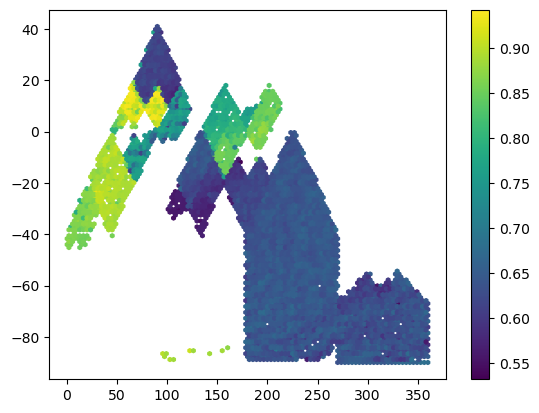

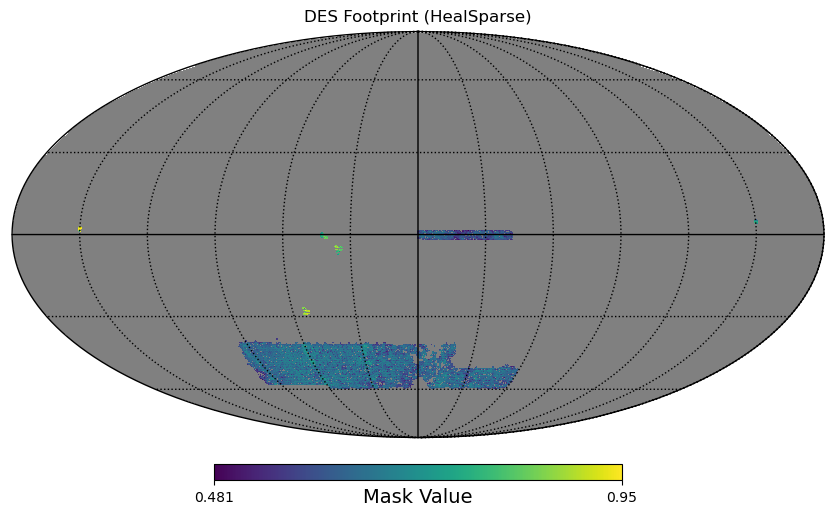

In [105]:
plot_map('/global/homes/k/kabelo/TXPipe/data/des/redmapper_y1a1_public_v6.4_zmask.fits.gz', partial=True)

In [110]:
def sample_coords(hsp_map, size):
    rz = des[['richness', 'redshift', 'scaleval']].sample(
        n=size, replace=True, random_state=43
    ).reset_index(drop=True)

    ra_out = np.empty(size)
    dec_out = np.empty(size)
    filled = 0

    while filled < size:
        needed = size - filled
        # Oversample — tune multiplier based on your acceptance rate
        batch = max(needed * 4, 1000)

        ra, dec = hs.make_uniform_randoms(hsp_map, batch)
        pix = hp.ang2pix(nside, ra, dec, lonlat=True)
        z_at_pos = zmask[pix]

        # Vectorized acceptance check
        # We compare against the redshifts for the *slots we still need to fill*
        z_needed = rz['redshift'].values[filled:filled + batch]
        # Guard against batch > remaining slots
        n_compare = min(batch, needed)
        mask = rz['redshift'].values[filled:filled + n_compare] <= z_at_pos[:n_compare]

        n_accept = mask.sum()
        if n_accept == 0:
            continue

        take = min(n_accept, needed)
        ra_out[filled:filled + take] = ra[:n_compare][mask][:take]
        dec_out[filled:filled + take] = dec[:n_compare][mask][:take]

        # Compact accepted rz rows into their final positions
        accepted_idx = np.where(mask)[0][:take]
        for j, idx in enumerate(accepted_idx):
            if filled + j < size:
                rz.iloc[filled + j] = rz.iloc[filled + idx]

        filled += take

    coords = pd.DataFrame({'ra': ra_out, 'dec': dec_out})
    return pd.concat([coords, rz], axis=1)


def create_random_cat(cluster_cat, hsp_map):
    size = len(cluster_cat) * 10
    random_df = sample_coords(hsp_map, size)
    # From this point we can use the scaleval and richness to get an effective richness,
    # then compare this to a cutoff richness (a la https://arxiv.org/abs/1601.00621) that acts like a loose detection mask,
    # then we only keep the randoms that pass this masking
    # Still needs a geometric mask on top of this 
    return random_df

In [111]:
start = time.time()

hsp_map, hpx_map = create_hsp_map('/global/homes/k/kabelo/TXPipe/data/des/redmapper_y1a1_public_v6.4_zmask.fits.gz', partial=True)
random_df = create_random_cat(des, hsp_map)

print(time.time() - start, ' s')

NSIDE: 4096
Map values: min=0.47600001096725464, max=0.9500000476837158
NSIDE: 4096
Map values: min=-1.637499996306027e+30, max=0.9500000476837158
Number of good pixels: 8037158
Pixels match: True
177.4509425163269  s


In [113]:
random_df.to_csv('/global/homes/k/kabelo/TXPipe/data/des/new_random_cat.csv')

In [115]:
config_file     = "examples/twopoint_cluster/config/config_clusters.yml" 
config_clusters = yaml.safe_load(open(config_file)) 
zbin_edges = config_clusters['TXTwoPointCluster']['redshift_bin_edges']
lbin_edges = config_clusters['TXTwoPointCluster']['richness_bin_edges']
infile = '/global/homes/k/kabelo/TXPipe/data/des/new_random_cat.csv'
outfile = '/global/homes/k/kabelo/TXPipe/data/des/new_random_cat.hdf5'
binned_dfs = bin_clusters(infile, zbin_edges, lbin_edges)
df_to_hdf5(binned_dfs, outfile)

NSIDE: 4096
Map values: min=1.0, max=3.0
NSIDE: 4096
Map values: min=-1.637499996306027e+30, max=3.0
Number of good pixels: 8841020
Pixels match: True


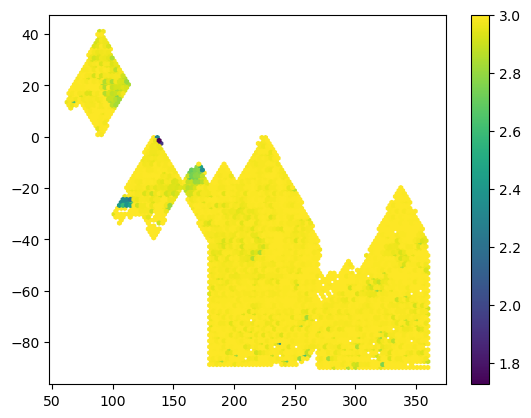

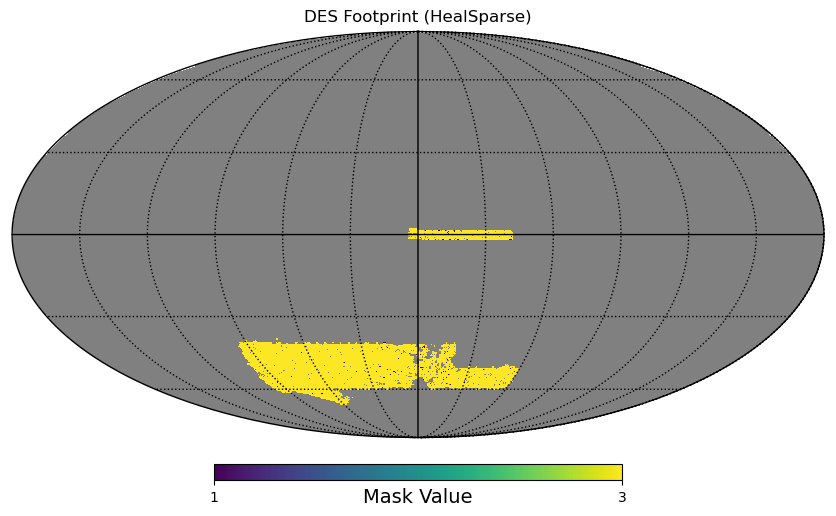

In [19]:
plot_map()

In [73]:
rdf['ra'].min()

np.float64(62.420243239095214)

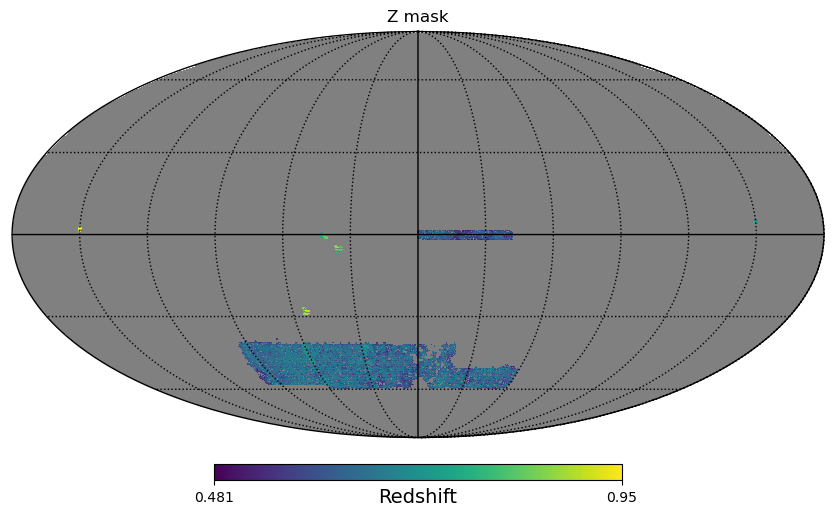

In [76]:
zmask = '/global/homes/k/kabelo/TXPipe/data/des/redmapper_y1a1_public_v6.4_zmask.fits.gz'
zmask = hp.read_map(zmask, partial=True)
hp.mollview(zmask, title='Z mask', unit='Redshift')
hp.graticule()
plt.show()

In [94]:
random_df

,ra,dec,richness,redshift,scaleval
0,332.246725,-56.758181,45.052155,0.408190,1.096756
1,334.204446,-57.930352,71.824631,0.476998,1.002852
2,328.916121,-59.204182,25.480021,0.275948,1.030075
3,338.113000,-59.289313,22.322241,0.420165,1.001833
4,53.957085,-29.966132,101.037910,0.461171,1.043269
...,...,...,...,...,...
667,319.496885,-59.613977,21.666277,0.413097,1.175853
668,335.231833,-57.956378,21.986631,0.622249,1.008287
669,333.177752,-58.204570,21.666277,0.413097,1.175853
670,336.114500,-59.361146,21.986631,0.622249,1.008287
